In [ ]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

def f(x, sigma):
    epsilon = np.random.randn(*x.shape) * sigma
    return 10 * np.sin(2 * np.pi * (x)) + epsilon

train_size = 32
noise = 1.0

X = np.linspace(-0.5, 0.5, train_size).reshape(-1, 1)
y = f(X, sigma=noise)
y_true = f(X, sigma=0.0)

plt.scatter(X, y, marker='+', label='Training data')
plt.plot(X, y_true, label='Truth')
plt.title('Noisy training data and ground truth')
plt.legend()

In [ ]:
import BNN

In [ ]:
import warnings
warnings.filterwarnings('ignore')

from keras.layers import Input
from keras.models import Model

batch_size = train_size
num_batches = train_size / batch_size

kl_weight = 1.0 / num_batches
prior_params = {
    'prior_sigma_1': 1.5, 
    'prior_sigma_2': 0.1, 
    'prior_pi': 0.5 
}

x_in = Input(shape=(1,))
x = BNN.DenseVariational(20, kl_weight, **prior_params, activation='relu')(x_in)
x = BNN.DenseVariational(20, kl_weight, **prior_params, activation='relu')(x)
x = BNN.DenseVariational(1, kl_weight, **prior_params)(x)

model = Model(x_in, x)

In [ ]:
len(model.get_weights())

In [ ]:
# from keras import callbacks, optimizers

# import tensorflow as tf
# import tensorflow_probability as tfp
# from keras import backend as K

# def neg_log_likelihood(y_obs, y_pred, sigma=noise):
#     dist = tfp.distributions.Normal(loc=y_pred, scale=sigma)
#     return K.sum(-dist.log_prob(y_obs))

# model.compile(loss=neg_log_likelihood, optimizer=optimizers.Adam(lr=0.08), metrics=['mse'])
# model.fit(X, y, batch_size=batch_size, epochs=1500, verbose=0)

In [ ]:
# import tqdm

# X_test = np.linspace(-1.5, 1.5, 1000).reshape(-1, 1)
# y_pred_list = []

# for i in tqdm.tqdm(range(500)):
#     y_pred = model.predict(X_test)
#     y_pred_list.append(y_pred)
    
# y_preds = np.concatenate(y_pred_list, axis=1)

# y_mean = np.mean(y_preds, axis=1)
# y_sigma = np.std(y_preds, axis=1)

In [ ]:
# plt.plot(X_test, y_mean, 'r-', label='Predictive mean');
# plt.scatter(X, y, marker='+', label='Training data')
# plt.fill_between(X_test.ravel(),
#                  y_mean + 2 * y_sigma,
#                  y_mean - 2 * y_sigma,
#                  alpha=0.5, label='Epistemic uncertainty')
# plt.title('Prediction')
# plt.legend()

On veut créer un petit réseau de neurone avec une seule couche caché avec Relu comme fonction d'activation


On a $w^{(k)}_j$ avec $k =1,2$ et $j = 1,2,3$

et $b^{(1)}_j$ avec $j = 1,2,3$ et $b^{(2)}$

$\hat{y} = (\sum_{k = 1}^3 w^{(2)}_k(Relu(x w^{(1)}_l + b^{(1)}_l))) + b^{(2)}$

In [18]:
import numpy as np
import pylab as plt


def simuler_theta() :
    w_1 = [np.random.normal() for i in range(20)]
    w_2 = [[np.random.normal() for i in range(20)] for i in range(20)]
    w_3 = [np.random.normal() for i in range(20)]
    b_1 = [np.random.normal() for i in range(20)]
    b_2 =[np.random.normal() for i in range(20)]
    b_3 = np.random.normal()
    return [w_1, w_2, w_3, b_1, b_2, b_3]

def Relu(x) :
    return x * (x >= 0)

def Leaky_Relu(x):
    return x * (x > 0) + 0.01*x* (x <= 0)

def sig(x) :
    return 1/(1 + np.exp(-x))

def FNN(x, theta) :
    w_1, w_2, w_3, b_1, b_2, b_3 = theta
    res = b_3
    for k in range(3) :
        s = b_2[k]
        for j in range(3) :
            s += w_2[j][k]*(sig(b_1[j] + x*w_1[j])) 
        res += w_3[k]*sig(s)
    return res

$\hat{y} = \sigma_3\left(b^{(3)} + \sum_{k = 1}^{20} w_k^{(3)} \left( \sigma_2 \left(b_k^{(2)} + \sum_{j = 1}^{20} w_{jk}^{(2)} \left( \sigma_1 \left(b_j^{(1)} + x w_j^{(1)}\right) \right) \right)\right)\right)$

In [19]:
FNN(1, simuler_theta())

1.294888874964271

In [ ]:
def generer_y(X,theta) :
    return np.array([FNN(x, theta) for x in X])

def rho(x,y) :
    return (x - y)**2

def eta(x) :
    return np.mean(x)

In [ ]:
def MMA(nb_samples,seed_theta, tol, X, y) :
    thetas = []
    y_hats = []
    for _ in range(nb_samples) :
        while True :
            step = simuler_theta()

            w_1 = [x + y for x,y in zip(step[0], seed_theta[0])]
            w_2 = [[x + y for x,y in zip(step[1][i], seed_theta[1][i])] for i in range(20)]
            w_3 = [x + y for x,y in zip(step[2], seed_theta[2])]
            b_1 = [x + y for x,y in zip(step[3], seed_theta[3])]
            b_2 = [x + y for x,y in zip(step[4], seed_theta[4])]
            b_3 = step[5] + seed_theta[5] 

            theta_new = [w_1, w_2, w_3, b_1, b_2, b_3]
            y_hat = generer_y(X, theta_new)            
            if(np.linalg.norm(y_hat - y) <= tol) :
                break
        seed_theta = theta_new
        thetas.append(seed_theta)
        y_hats.append(y_hat)
    return thetas, y_hats

In [ ]:
plt.plot(X, generer_y(X,simuler_theta()))

In [ ]:
'''
ABC Naïf 
'''
Nmax = 1
epsilon = 1000
thetas = []
y_hats = []
for n in range(Nmax) :
    while True :
        theta = simuler_theta() # Simuler theta avec la loi sa loi a priori
        y_hat = generer_y(X,theta) # generer y_hat avec le theta simuler à l'aide du FNN
        # if((rho(eta(y_hat), eta(y))) <= epsilon) :# On garde de couple si y et y_hat sont assez'similaire' 
        #     break

        if( sum((y_hat - y) * (y_hat - y))[0] <= epsilon) :
            break
        # On collecte les cas favorables pour simuler leur distribution
    thetas.append(theta)
    y_hats.append(y_hat)

In [32]:
N = 50
m = 30
P0 = 0.2
epsilon = 0.1
import numpy as np
thetas = [simuler_theta() for i in range(0, N)]
y_hats = [generer_y(X,theta) for theta in thetas]

l = []
for j in range(0, m) : 

    rho_n = []
    for n in range(0, N) :
        rho_n.append(np.linalg.norm(y_hats[n] - y))

    new_indices = list(np.argsort(rho_n))
    thetas = list(np.array(thetas)[new_indices])
    y_hats = list(np.array(y_hats)[new_indices])
    rho_n = list(np.array(rho_n)[new_indices])

    epsilon_j = (rho_n[int(N*P0)] + rho_n[int(N*P0) + 1])/2

    new_thetas = []
    new_y_hats = []
    for k in range(0, int(N*P0)) :
        t1, t2  = MMA(nb_samples = int(1/P0),seed_theta = thetas[k], tol = epsilon_j, X = X,y = y)

        new_thetas += t1
        new_y_hats += t2

    thetas = new_thetas
    y_hats = new_y_hats

    l.append(epsilon_j)
    if epsilon_j <= epsilon :
        break

KeyboardInterrupt: 

In [33]:
j

15

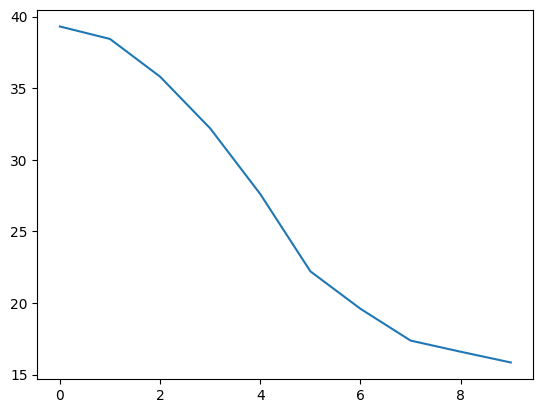

In [30]:
plt.plot(l)